## Let the Neurons Die Part II - Poisoned Data Construction with the idea of Inverting Gradients Attack

This notebook is an example for reconstructing input training data in a malicious way using weight and gradient information. The reconstructed datapoint(s) will be used for victim model training and the expected outcome should be seeing dead neurons and model never being converged. The model is a custom model with **ReLu** activation function.

### Startup

The startup code should be the same as the *Inverting Gradients Attack*.
Please note that in order to be 100% that we are running the modified `breaching` framework, remember to uninstall the `breaching` library if you installed the package before via `pip3 uninstall breaching`.

In [2]:
try:
    import breaching
except ModuleNotFoundError:
    # You only really need this safety net if you want to run these notebooks directly in the examples directory
    # Don't worry about this if you installed the package or moved the notebook to the main directory.
    import os; os.chdir("..")
    import breaching
    
import torch
import numpy as np
%load_ext autoreload
%autoreload 2

# Redirects logs directly into the jupyter notebook
import logging, sys
logging.basicConfig(level=logging.INFO, handlers=[logging.StreamHandler(sys.stdout)], format='%(message)s')
logger = logging.getLogger()

### Initialize cfg object and system setup:
This will load the full configuration object. This includes the configuration for the use case and threat model as `cfg.case` and the hyperparameters and implementation of the attack as `cfg.attack`. All parameters can be modified below, or overriden with `overrides=` as if they were cmd-line arguments.

In [3]:
# Uncomment if create one single poisoned data point
# cfg = breaching.get_config(overrides=["case=11_single_mnist", "attack=invertinggradients"])

# Uncomment if create a batch of poisoned data points
cfg = breaching.get_config(overrides=["case=12_batch_mnist", "attack=invertinggradients"])
          
device = torch.device(f'cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.backends.cudnn.benchmark = cfg.case.impl.benchmark
setup = dict(device=device, dtype=getattr(torch, cfg.case.impl.dtype))
setup

Investigating use case single_mnist with server type honest_but_curious.


{'device': device(type='cuda'), 'dtype': torch.float32}

### Modify config options here

You can use `.attribute` access to modify any of these configurations for the attack, or the case:

In [4]:
cfg.case.data.partition="unique-class"
cfg.case.user.user_idx = 1
cfg.case.model='customnet'

### Instantiate all parties

The following lines generate "server, "user" and "attacker" objects and print an overview of their configurations.

In [5]:
user, server, model, loss_fn = breaching.cases.construct_case(cfg.case, setup)
attacker = breaching.attacks.prepare_attack(server.model, server.loss, cfg.attack, setup)
breaching.utils.overview(server, user, attacker)

[array([[-1.40454825e-02, -2.96367947e-02, -3.73193156e-03, ...,
        -3.65462787e-02, -3.13980095e-02, -3.38774137e-02],
       [-1.27887763e-02, -1.53172892e-02,  2.17504054e-02, ...,
         2.31493711e-02, -2.01520436e-02, -2.02382822e-02],
       [ 1.95875578e-03,  3.46289575e-02,  8.97457357e-03, ...,
        -3.43139432e-02,  1.22368848e-02,  1.85355004e-02],
       ...,
       [-8.33072793e-03,  9.51768085e-03,  1.86587572e-02, ...,
         2.87100747e-02, -2.81406082e-02, -9.47865471e-03],
       [-2.38090269e-02,  2.36297399e-02,  2.84052975e-02, ...,
        -2.00361498e-02,  8.53443562e-05, -1.66687742e-02],
       [-2.55207699e-02,  1.75241344e-02,  2.65778936e-02, ...,
        -3.56049603e-03,  2.96540298e-02,  2.52249800e-02]], dtype=float32), array([[ 0.00133343, -0.03005386, -0.04002051, ..., -0.036305  ,
         0.02381881, -0.04132118],
       [ 0.02489064, -0.00579297,  0.0146622 , ...,  0.00518307,
        -0.03085754,  0.0259238 ],
       [-0.00692874,  0.01

### Simulate an attack

Just like *Inverting Gradients Attack*, this exchange is a simulation of a single query in a federated learning protocol. The server sends out a `server_payload` and the user computes an update based on their private local data. This user update is `shared_data` and contains, for example, the parameter gradient of the model in the simplest case. `true_user_data` is also returned by `.compute_local_updates`, but of course not forwarded to the server or attacker and only used for (our) analysis.

In [6]:
server_payload = server.distribute_payload()
shared_data, true_user_data = user.compute_local_updates(server_payload)

INFO:breaching.cases.users:Computing user update on user 1 in model mode: eval.


torch.Size([50, 1, 28, 28])


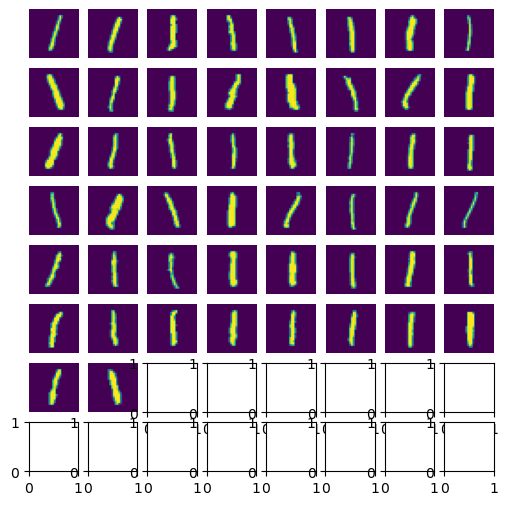

In [7]:
# For single reconstruction testing purpose
print(true_user_data['data'].shape)
user.plot(true_user_data)

### Reconstruct input datapoint(s):

Now we launch the attack, reconstructing user data based on only the `server_payload` and the `shared_data`. 

You can interrupt the computation early to see a partial solution.

**Note that the objective for our attack deviates from the Inverting Gradients Attack since we aim to reconstruct poisoned datapoint(s) with preset gradients information and try to kill the activated neurons.**

In [8]:
print(shared_data['gradients'][0].shape)
reconstructed_user_data, stats = attacker.reconstruct([server_payload], [shared_data], {}, dryrun=cfg.dryrun)

INFO:breaching.attacks.base_attack:Recovered labels [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.9488 |  Task loss: 2.2929 | T: 0.09s


torch.Size([392, 784])


INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.5531 |  Task loss: 2.2934 | T: 4.30s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.5661 |  Task loss: 2.2934 | T: 3.19s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.5561 |  Task loss: 2.2934 | T: 3.19s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.5642 |  Task loss: 2.2934 | T: 3.14s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.5751 |  Task loss: 2.2934 | T: 3.13s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.5665 |  Task loss: 2.2934 | T: 3.15s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.5721 |  Task loss: 2.2934 | T: 3.17s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.5606 |  Task loss: 2.2934 | T: 3.20s
INFO:breaching.attacks.optimization_based_attack:| It: 9001 | Rec. loss: 0.5644 |  Task loss: 2.2934 | T

We can plot the reconstructed data for testing purpose:

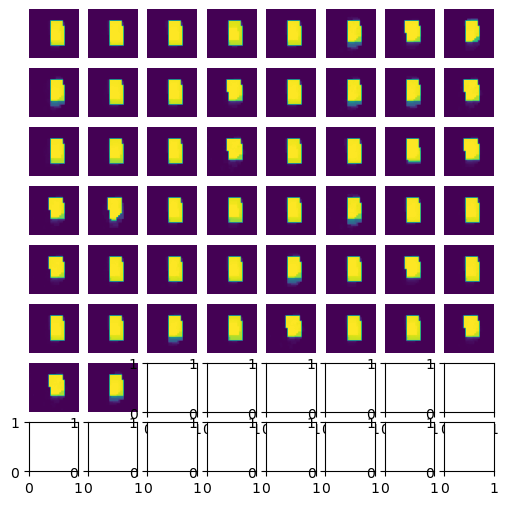

In [9]:
user.plot(reconstructed_user_data)

In [10]:
torch.save(reconstructed_user_data, 'reconstructed_user_data_12_batch.pt')

In [11]:
np.save('reconstructed_user_data_12_batch.npy', reconstructed_user_data)

## For single data point:

In [13]:
# Uncomment if create one single poisoned data point
cfg = breaching.get_config(overrides=["case=11_single_mnist", "attack=invertinggradients"])

# Uncomment if create a batch of poisoned data points
# cfg = breaching.get_config(overrides=["case=12_batch_mnist", "attack=invertinggradients"])
          
device = torch.device(f'cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.backends.cudnn.benchmark = cfg.case.impl.benchmark
setup = dict(device=device, dtype=getattr(torch, cfg.case.impl.dtype))
setup

cfg.case.data.partition="unique-class"
cfg.case.user.user_idx = 1
cfg.case.model='customnet'

user, server, model, loss_fn = breaching.cases.construct_case(cfg.case, setup)
attacker = breaching.attacks.prepare_attack(server.model, server.loss, cfg.attack, setup)
breaching.utils.overview(server, user, attacker)

server_payload = server.distribute_payload()
shared_data, true_user_data = user.compute_local_updates(server_payload)


INFO:breaching.cases.users:Computing user update on user 1 in model mode: eval.


Investigating use case single_mnist with server type honest_but_curious.
[array([[-1.40454825e-02, -2.96367947e-02, -3.73193156e-03, ...,
        -3.65462787e-02, -3.13980095e-02, -3.38774137e-02],
       [-1.27887763e-02, -1.53172892e-02,  2.17504054e-02, ...,
         2.31493711e-02, -2.01520436e-02, -2.02382822e-02],
       [ 1.95875578e-03,  3.46289575e-02,  8.97457357e-03, ...,
        -3.43139432e-02,  1.22368848e-02,  1.85355004e-02],
       ...,
       [-8.33072793e-03,  9.51768085e-03,  1.86587572e-02, ...,
         2.87100747e-02, -2.81406082e-02, -9.47865471e-03],
       [-2.38090269e-02,  2.36297399e-02,  2.84052975e-02, ...,
        -2.00361498e-02,  8.53443562e-05, -1.66687742e-02],
       [-2.55207699e-02,  1.75241344e-02,  2.65778936e-02, ...,
        -3.56049603e-03,  2.96540298e-02,  2.52249800e-02]], dtype=float32), array([[ 0.00133343, -0.03005386, -0.04002051, ..., -0.036305  ,
         0.02381881, -0.04132118],
       [ 0.02489064, -0.00579297,  0.0146622 , ...,  

torch.Size([1, 1, 28, 28])


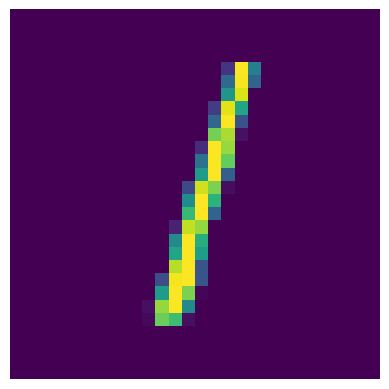

In [14]:

# For single reconstruction testing purpose
print(true_user_data['data'].shape)
user.plot(true_user_data)

In [15]:
print(shared_data['gradients'][0].shape)
reconstructed_user_data, stats = attacker.reconstruct([server_payload], [shared_data], {}, dryrun=cfg.dryrun)

INFO:breaching.attacks.base_attack:Recovered labels [1] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 1.2208 |  Task loss: 2.2907 | T: 0.01s


torch.Size([392, 784])


INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.6019 |  Task loss: 2.2923 | T: 3.14s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.5969 |  Task loss: 2.2924 | T: 3.15s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.6016 |  Task loss: 2.2924 | T: 3.12s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.6015 |  Task loss: 2.2923 | T: 2.86s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.6016 |  Task loss: 2.2923 | T: 3.01s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.6019 |  Task loss: 2.2923 | T: 3.21s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.6012 |  Task loss: 2.2923 | T: 3.09s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.6018 |  Task loss: 2.2923 | T: 3.38s
INFO:breaching.attacks.optimization_based_attack:| It: 9001 | Rec. loss: 0.6010 |  Task loss: 2.2922 | T

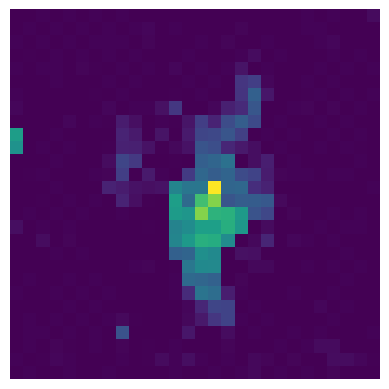

: 

In [18]:
user.plot(reconstructed_user_data)

In [16]:
torch.save(reconstructed_user_data, 'reconstructed_user_data_11_single.pt')

In [17]:
np.save('reconstructed_user_data_11_single.npy', reconstructed_user_data)